In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("analysis data.csv")

###Create customer churn Table

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Convert date
df['order_purchase_timestamp'] = pd.to_datetime(
    df['order_purchase_timestamp']
)

# Reference date
snapshot_date = (
    df['order_purchase_timestamp'].max()
    + pd.Timedelta(days=1)
)

# Customer-level table
customer_churn = (
    df.groupby('customer_unique_id')
    .agg({
        'order_purchase_timestamp':'max',
        'order_id':'nunique',
        'revenue':'sum'
    })
    .reset_index()
)

customer_churn.columns = [
    'CustomerID',
    'LastPurchaseDate',
    'Frequency',
    'Revenue'
]

# Recency
customer_churn['Recency'] = (
    snapshot_date -
    customer_churn['LastPurchaseDate']
).dt.days

Define churn Status

In [ ]:
def churn_status(recency):

    if recency <= 90:
        return 'Active'

    elif recency <= 180:
        return 'At Risk'

    else:
        return 'Churned'

customer_churn['Churn_Status'] = (
    customer_churn['Recency']
    .apply(churn_status)
)

###churn Summary Table

In [ ]:
churn_summary = (
    customer_churn['Churn_Status']
    .value_counts()
    .reset_index()
)

churn_summary.columns = [
    'Churn_Status',
    'Customer_Count'
]

churn_summary

,Churn_Status,Customer_Count
0,Churned,8097
1,At Risk,2478
2,Active,1825


###Churn Rate

In [ ]:
total_customers = len(customer_churn)

churned_customers = len(
    customer_churn[
        customer_churn['Churn_Status']
        == 'Churned'
    ]
)

churn_rate = (
    churned_customers /
    total_customers
) * 100

print(
    f"Churn Rate: {churn_rate:.2f}%"
)

Churn Rate: 65.30%


###churn  Distribution Graph

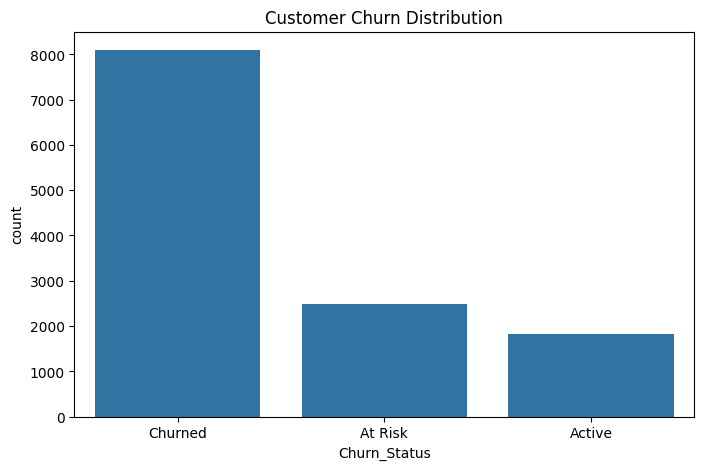

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=customer_churn,
    x='Churn_Status'
)

plt.title(
    'Customer Churn Distribution'
)

plt.show()

###Revenue by churn Status

In [ ]:
revenue_by_status = (
    customer_churn
    .groupby('Churn_Status')
    ['Revenue']
    .sum()
    .reset_index()
)

revenue_by_status

,Churn_Status,Revenue
0,Active,213228.35
1,At Risk,304768.48
2,Churned,917416.47


###Revenue loss from churned Customera

In [ ]:
revenue_lost = (
    customer_churn[
        customer_churn['Churn_Status']
        == 'Churned'
    ]['Revenue']
    .sum()
)

print(
    f"Revenue Lost Due to Churn: {revenue_lost:,.2f}"
)

Revenue Lost Due to Churn: 917,416.47


###Revenue contribution %

In [ ]:
revenue_by_status['Revenue_Percentage'] = (
    revenue_by_status['Revenue']
    /
    revenue_by_status['Revenue'].sum()
) * 100

revenue_by_status

,Churn_Status,Revenue,Revenue_Percentage
0,Active,213228.35,14.854840
1,At Risk,304768.48,21.232106
2,Churned,917416.47,63.913053


###REvenue Distribution Graph

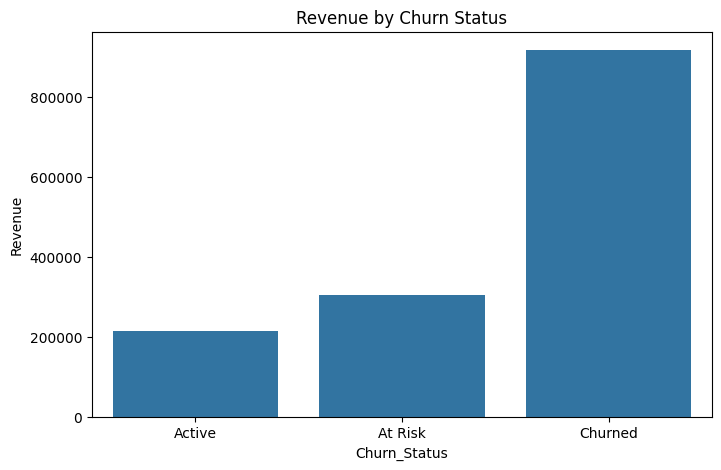

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=revenue_by_status,
    x='Churn_Status',
    y='Revenue'
)

plt.title(
    'Revenue by Churn Status'
)

plt.show()

###Revenue share pie chart

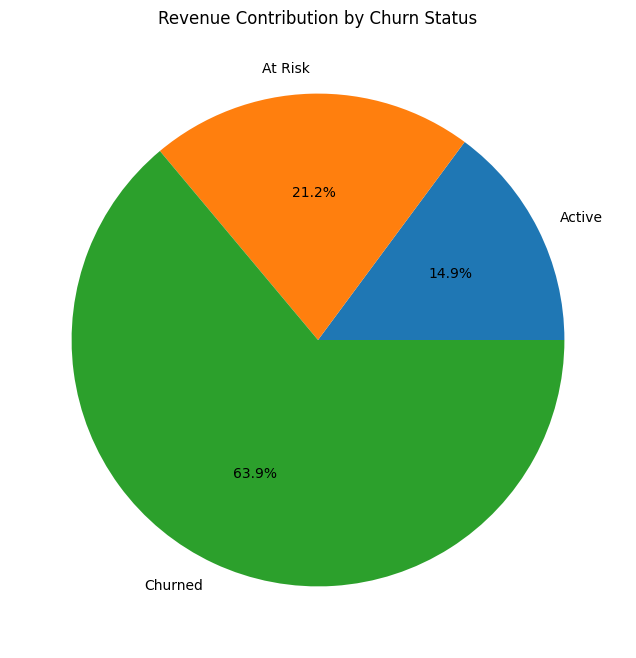

In [ ]:
plt.figure(figsize=(8,8))

plt.pie(
    revenue_by_status['Revenue'],
    labels=revenue_by_status['Churn_Status'],
    autopct='%1.1f%%'
)

plt.title(
    'Revenue Contribution by Churn Status'
)

plt.show()

###Top 10 High-Value Churned Customers

In [ ]:
top10_churned = (
    customer_churn[
        customer_churn['Churn_Status']
        == 'Churned'
    ]
    .sort_values(
        'Revenue',
        ascending=False
    )
    .head(10)
)

top10_churned

,CustomerID,LastPurchaseDate,Frequency,Revenue,Recency,Churn_Status
11578,edf81e1f3070b9dac83ec83dacdbb9bc,2017-04-18 20:37:26,1,7998.00,520,Churned
4101,53fb3435773a4690e56010b169ee2820,2018-02-09 14:43:53,1,3099.90,223,Churned
6633,895617ab63a9ad8881d9470f7427cd25,2017-10-05 19:23:16,1,2999.99,350,Churned
4734,6172bd5b7f52ade8c6c4548b448ff54f,2017-07-06 14:51:37,1,2999.89,441,Churned
6134,7efc49d7862ee114c0ca869b439bf381,2017-11-04 09:35:15,1,2874.00,321,Churned
11375,e92a2a874e305a7e920b0a0b308d5890,2017-10-11 09:50:15,1,2680.00,345,Churned
9799,c949c73b1318491d6b5b117acb3e24a4,2017-06-02 09:19:00,1,2649.00,476,Churned
1818,2573467bea86fae9af4db442a1ef23bc,2017-05-02 10:18:30,1,2338.88,507,Churned
5308,6d443b75cff956bb73dce7385033e266,2017-09-05 09:29:17,1,2105.40,381,Churned
1233,18d3c0c7617e44eab9bef19f29bbdb1b,2017-06-19 09:59:58,1,1999.99,459,Churned


###Churned Customers Graph

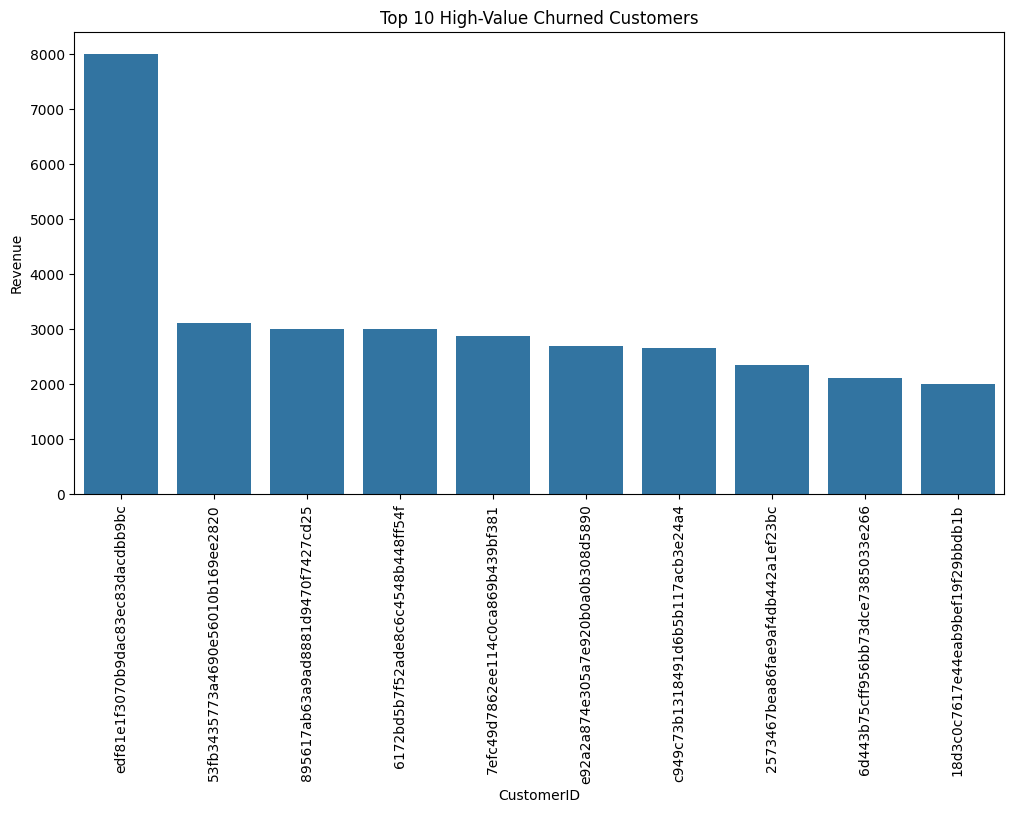

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_churned,
    x='CustomerID',
    y='Revenue'
)

plt.xticks(rotation=90)

plt.title(
    'Top 10 High-Value Churned Customers'
)

plt.show()

###Attach State Information

In [ ]:
customer_state = (
    df.groupby('customer_unique_id')
    ['customer_state']
    .first()
    .reset_index()
)

customer_state.columns = [
    'CustomerID',
    'State'
]

customer_churn = customer_churn.merge(
    customer_state,
    on='CustomerID',
    how='left'
)

###State-wise Churn Table

In [ ]:
state_churn = pd.crosstab(
    customer_churn['State'],
    customer_churn['Churn_Status']
)

state_churn

Churn_Status,Active,At Risk,Churned
State,,,
AC,2,1,15
AL,7,8,36
AM,2,7,7
AP,0,0,4
BA,62,87,275
CE,18,35,126
DF,41,49,151
ES,32,59,152
GO,40,46,175


###Churn Rate by State

In [ ]:
state_churn_rate = state_churn.copy()

state_churn_rate['Total_Customers'] = (
    state_churn_rate.sum(axis=1)
)

state_churn_rate['Churn_Rate'] = (
    state_churn_rate['Churned']
    /
    state_churn_rate['Total_Customers']
) * 100

state_churn_rate = (
    state_churn_rate
    .sort_values(
        'Churn_Rate',
        ascending=False
    )
)

state_churn_rate

Churn_Status,Active,At Risk,Churned,Total_Customers,Churn_Rate
State,,,,,
AP,0,0,4,4,100.000000
RR,1,0,6,7,85.714286
AC,2,1,15,18,83.333333
RO,2,3,23,28,82.142857
PA,14,18,102,134,76.119403
MT,10,16,75,101,74.257426
MS,9,15,64,88,72.727273
MA,12,13,63,88,71.590909
PI,6,12,45,63,71.428571


###Top 10 States with Highest Churn

In [ ]:
top10_churn_states = (
    state_churn_rate
    .sort_values(
        'Churn_Rate',
        ascending=False
    )
    .head(10)
)

top10_churn_states

Churn_Status,Active,At Risk,Churned,Total_Customers,Churn_Rate
State,,,,,
AP,0,0,4,4,100.000000
RR,1,0,6,7,85.714286
AC,2,1,15,18,83.333333
RO,2,3,23,28,82.142857
PA,14,18,102,134,76.119403
MT,10,16,75,101,74.257426
MS,9,15,64,88,72.727273
MA,12,13,63,88,71.590909
PI,6,12,45,63,71.428571


###Top 10 States with Lowest Churn

In [ ]:
lowest_churn_states = (
    state_churn_rate
    .sort_values(
        'Churn_Rate'
    )
    .head(10)
)

lowest_churn_states

Churn_Status,Active,At Risk,Churned,Total_Customers,Churn_Rate
State,,,,,
AM,2,7,7,16,43.750000
SE,13,6,30,49,61.224490
ES,32,59,152,243,62.551440
DF,41,49,151,241,62.655602
SP,851,1086,3294,5231,62.970751
BA,62,87,275,424,64.858491
PR,90,127,402,619,64.943457
SC,56,99,291,446,65.246637
PB,13,13,51,77,66.233766


###State-wise Churn Heatmap

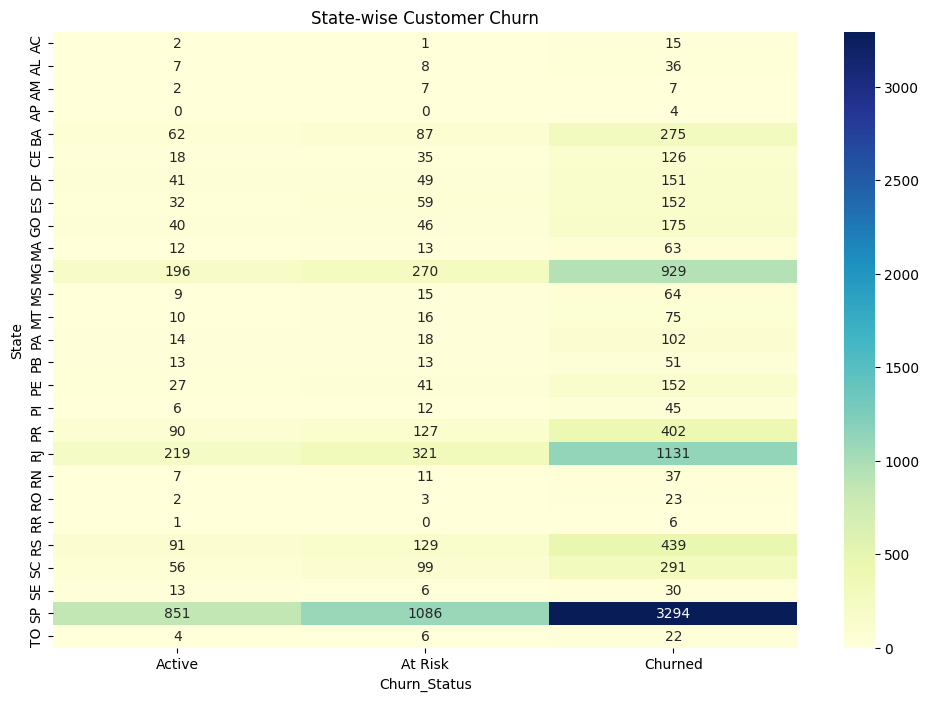

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    state_churn,
    annot=True,
    fmt='d',
    cmap='YlGnBu'
)

plt.title(
    'State-wise Customer Churn'
)

plt.show()

###Revenue Loss by State

In [ ]:
churned_customers = customer_churn[
    customer_churn['Churn_Status']
    == 'Churned'
]

revenue_loss_state = (
    churned_customers
    .groupby('State')
    ['Revenue']
    .sum()
    .reset_index()
    .sort_values(
        'Revenue',
        ascending=False
    )
)

revenue_loss_state.head(10)

,State,Revenue
25,SP,343480.54
18,RJ,131181.81
10,MG,94082.77
17,PR,52372.52
22,RS,49062.89
23,SC,34000.44
4,BA,32351.05
6,DF,23490.32
8,GO,21024.16
5,CE,20056.31


###Top Revenue Loss States Graph

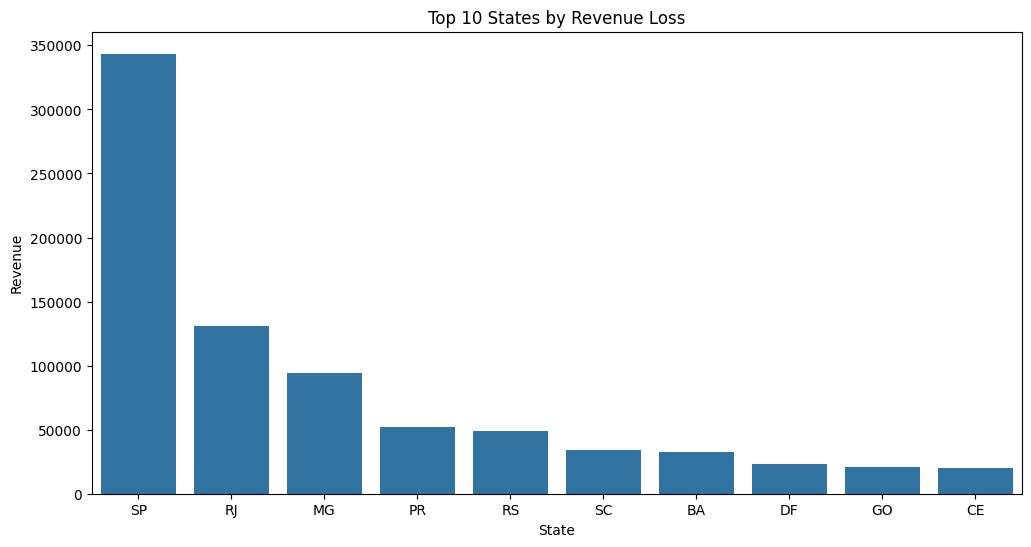

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=revenue_loss_state.head(10),
    x='State',
    y='Revenue'
)

plt.title(
    'Top 10 States by Revenue Loss'
)

plt.show()

###Get Churned Customer IDs

In [ ]:
churned_ids = customer_churn[
    customer_churn['Churn_Status']
    == 'Churned'
]['CustomerID']

###Filter Orders from Churned Customers

In [ ]:
churned_orders = df[
    df['customer_unique_id']
    .isin(churned_ids)
]

print(churned_orders.shape)

(9441, 39)


###Top Product Categories Purchased by Churned Customers

In [ ]:
top_churn_products = (
    churned_orders
    .groupby('product_category_name_english')
    ['order_id']
    .count()
    .reset_index()
    .rename(
        columns={
            'order_id':'Orders'
        }
    )
    .sort_values(
        'Orders',
        ascending=False
    )
)

top_churn_products.head(10)

,product_category_name_english,Orders
0,Unknown,1785
7,bed_bath_table,732
38,furniture_decor,655
61,sports_leisure,628
15,computers_accessories,600
42,health_beauty,554
48,housewares,426
66,watches_gifts,371
64,telephony,335
65,toys,333


###Graph: Top Churned Product Categories

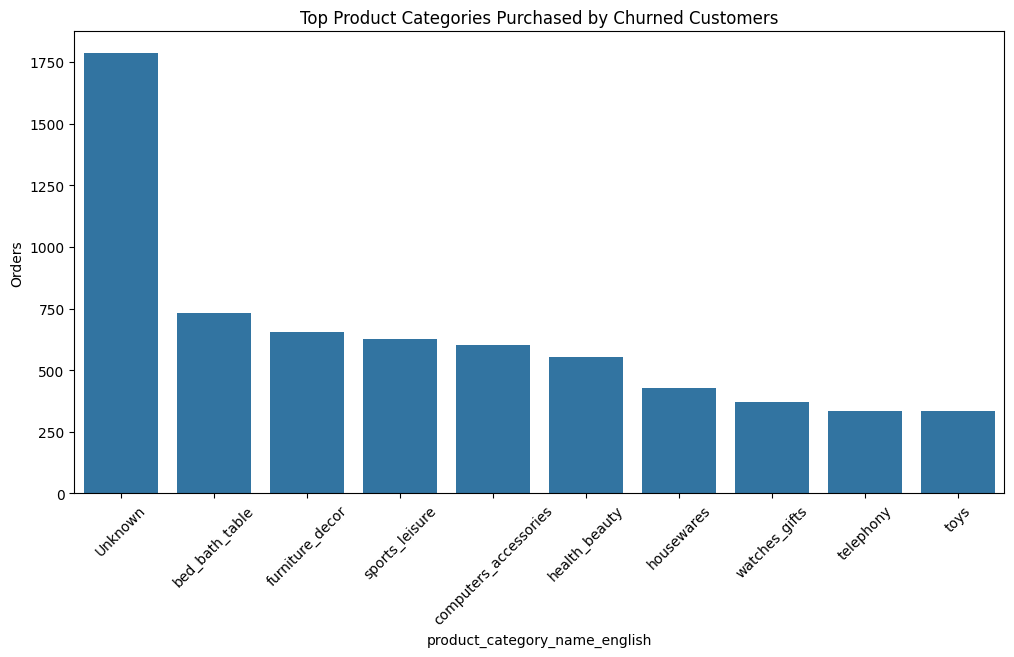

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_churn_products.head(10),
    x='product_category_name_english',
    y='Orders'
)

plt.xticks(rotation=45)

plt.title(
    'Top Product Categories Purchased by Churned Customers'
)

plt.show()

###Revenue Lost by Product Category

In [ ]:
product_revenue_loss = (
    churned_orders
    .groupby(
        'product_category_name_english'
    )
    ['revenue']
    .sum()
    .reset_index()
    .sort_values(
        'revenue',
        ascending=False
    )
)

product_revenue_loss.head(10)

,product_category_name_english,revenue
66,watches_gifts,75423.47
61,sports_leisure,74622.38
15,computers_accessories,73450.17
7,bed_bath_table,68788.06
42,health_beauty,66743.81
20,cool_stuff,53924.48
38,furniture_decor,53238.99
65,toys,42562.08
48,housewares,37967.07
5,auto,34777.58


###Graph: Revenue Loss by Product Category

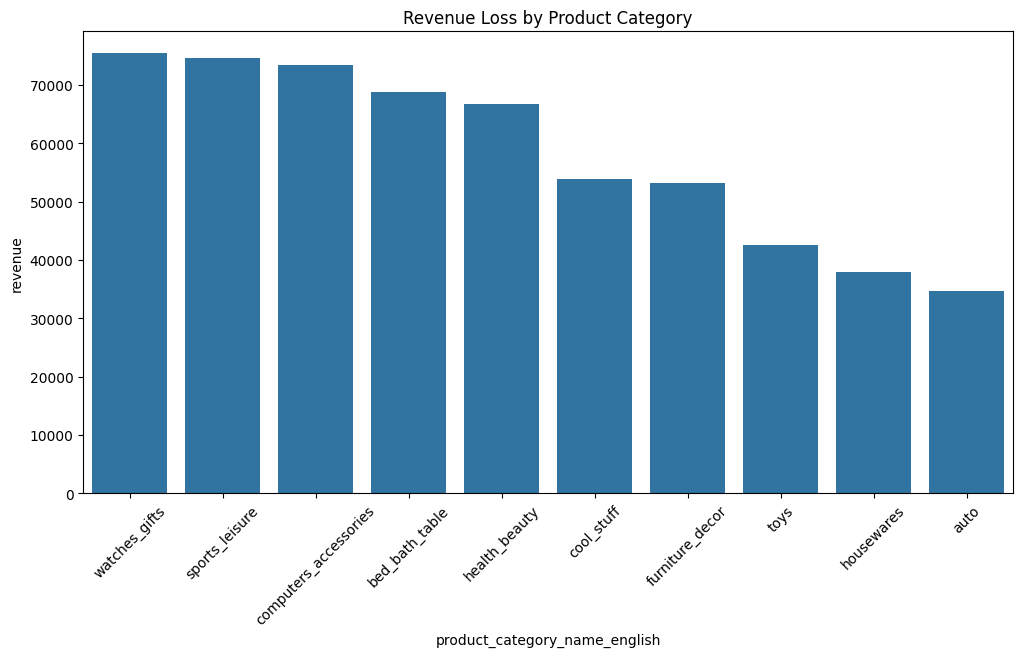

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=product_revenue_loss.head(10),
    x='product_category_name_english',
    y='revenue'
)

plt.xticks(rotation=45)

plt.title(
    'Revenue Loss by Product Category'
)

plt.show()

###Churn Rate by Product Category

In [ ]:
product_customer_total = (
    df.groupby(
        'product_category_name_english'
    )
    ['customer_unique_id']
    .nunique()
)

In [ ]:
product_customer_churn = (
    churned_orders
    .groupby(
        'product_category_name_english'
    )
    ['customer_unique_id']
    .nunique()
)

In [ ]:
product_churn_rate = pd.concat(
    [
        product_customer_total,
        product_customer_churn
    ],
    axis=1
)

product_churn_rate.columns = [
    'Total_Customers',
    'Churned_Customers'
]

product_churn_rate.fillna(
    0,
    inplace=True
)

product_churn_rate['Churn_Rate'] = (
    product_churn_rate[
        'Churned_Customers'
    ]
    /
    product_churn_rate[
        'Total_Customers'
    ]
) * 100

product_churn_rate = (
    product_churn_rate
    .sort_values(
        'Churn_Rate',
        ascending=False
    )
)

product_churn_rate.head(10)

,Total_Customers,Churned_Customers,Churn_Rate
product_category_name_english,,,
furniture_mattress_and_upholstery,3,3.0,100.000000
home_comfort_2,3,3.0,100.000000
fashion_childrens_clothes,1,1.0,100.000000
fashion_sport,6,6.0,100.000000
flowers,3,3.0,100.000000
cds_dvds_musicals,1,1.0,100.000000
fashion_male_clothing,13,12.0,92.307692
tablets_printing_image,10,9.0,90.000000
fashion_shoes,22,19.0,86.363636


###Product Churn Heatmap

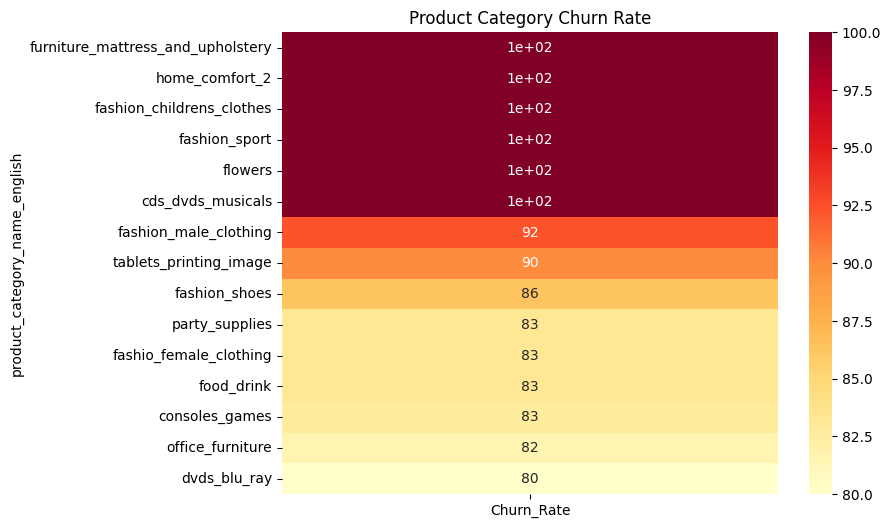

In [ ]:
top15 = (
    product_churn_rate
    .head(15)
)

plt.figure(figsize=(8,6))

sns.heatmap(
    top15[['Churn_Rate']],
    annot=True,
    cmap='YlOrRd'
)

plt.title(
    'Product Category Churn Rate'
)

plt.show()

###High-Value Churned Customers and Their Products

In [ ]:
top_churned_customers = (
    customer_churn[
        customer_churn['Churn_Status']
        == 'Churned'
    ]
    .sort_values(
        'Revenue',
        ascending=False
    )
    .head(10)
)

In [ ]:
high_value_products = (
    df[
        df['customer_unique_id']
        .isin(
            top_churned_customers[
                'CustomerID'
            ]
        )
    ]
    ['product_category_name_english']
    .value_counts()
)

high_value_products

,count
product_category_name_english,
housewares,6
Unknown,6
computers,5
watches_gifts,2
small_appliances,2
computers_accessories,1
construction_tools_safety,1
cool_stuff,1
auto,1


In [ ]:
churn_conclusion = pd.DataFrame({

    'Metric': [
        'Total Customers',
        'Active Customers',
        'At Risk Customers',
        'Churned Customers',
        'Churn Rate (%)',
        'Revenue Lost',
        'Top Churn State',
        'Top Revenue Loss State',
        'Top Churn Product',
        'Top Revenue Loss Product'
    ],

    'Value': [
        len(customer_churn),

        len(customer_churn[
            customer_churn['Churn_Status']
            == 'Active'
        ]),

        len(customer_churn[
            customer_churn['Churn_Status']
            == 'At Risk'
        ]),

        len(customer_churn[
            customer_churn['Churn_Status']
            == 'Churned'
        ]),

        round(churn_rate,2),

        revenue_lost,

        top10_churn_states.index[0],

        revenue_loss_state.iloc[0]['State'],

        top_churn_products.iloc[0]['product_category_name_english'],

        product_revenue_loss.iloc[0]['product_category_name_english']
    ]
})

churn_conclusion

,Metric,Value
0,Total Customers,12400
1,Active Customers,1825
2,At Risk Customers,2478
3,Churned Customers,8097
4,Churn Rate (%),65.3
5,Revenue Lost,917416.47
6,Top Churn State,AP
7,Top Revenue Loss State,SP
8,Top Churn Product,Unknown
9,Top Revenue Loss Product,watches_gifts
